# **Trabalho de Redes Neurais de Valor Hipercomplexo (MS904)**
# Comparação entre CNN tradicional e CNNs hipercomplexas para Classificação de Imagens

## Bibliotecas utilizadas


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tensorflow as tf
import tensorflow.keras as kr

from tensorflow.keras.layers import Layer
from tensorflow.keras import activations, initializers, regularizers
from tensorflow.keras import layers, models


In [ ]:
import requests
import os
url = "https://raw.githubusercontent.com/mevalle/v-nets/main/V_Nets.py"
response = requests.get(url)

if response.status_code == 200:
    with open("V_Nets.py", "wb") as f:
        f.write(response.content)
    print("V_Nets.py downloaded successfully.")
else:
    print(f"Failed to download V_Nets.py. Status code: {response.status_code}")

V_Nets.py downloaded successfully.


In [ ]:
from V_Nets import get_algebra, print_algebra
from V_Nets import V_Conv2D

## Carregando a base de dados - MedMNIST

In [ ]:
 !pip install medmnist
 from medmnist import DermaMNIST

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.3 MB/s eta 0:00:00


In [ ]:
im_size = 64

train_dataset = DermaMNIST(split='train', download=True, as_rgb=True, size=im_size)
x_train, y_train = train_dataset.imgs, train_dataset.labels

validation_dataset = DermaMNIST(split='val', download=True, as_rgb=True, size=im_size)
x_val, y_val = validation_dataset.imgs, validation_dataset.labels

test_dataset = DermaMNIST(split='test', download=True, as_rgb=True, size=im_size)
x_test, y_test = test_dataset.imgs, test_dataset.labels

print("Training dataset loaded:", train_dataset)
print("Validation dataset loaded:", validation_dataset)
print("Test dataset loaded:", test_dataset)

100%|██████████| 100M/100M [01:45<00:00, 950kB/s]  


Training dataset loaded: Dataset DermaMNIST of size 64 (dermamnist_64)
    Number of datapoints: 7007
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0
Validation dataset loaded: Dataset DermaMNIS

In [ ]:
import numpy as np
DermaMNIST_CLASSES = [
    'akiec',
    'bcc',
    'bkl',
    'df',
    'nv',
    'mel',
    'vasc'
]
classes, contagens = np.unique(y_train, return_counts=True)

for c, n in zip(classes, contagens):
    print(f"{DermaMNIST_CLASSES[c]}: {n}, {n/7007:.4f}")

akiec: 228, 0.0325
bcc: 359, 0.0512
bkl: 769, 0.1097
df: 80, 0.0114
nv: 779, 0.1112
mel: 4693, 0.6698
vasc: 99, 0.0141


# Álgebras hipercomplexas - formas bilineares

## Quatérnios

In [ ]:
Q = get_algebra('quaternions')
print_algebra(Q)

Bilinear form of the 0-th component.
[[ 1.  0.  0.  0.]
 [ 0. -1.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]
Bilinear form of the 1-th component.
[[ 0.  1.  0.  0.]
 [ 1.  0.  0.  0.]
 [ 0.  0.  0.  1.]
 [ 0.  0. -1.  0.]]
Bilinear form of the 2-th component.
[[ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]
 [ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]]
Bilinear form of the 3-th component.
[[ 0.  0.  0.  1.]
 [ 0.  0.  1.  0.]
 [ 0. -1.  0.  0.]
 [ 1.  0.  0.  0.]]


## Tessarinos

In [ ]:
T = np.stack([[[1,0,0,0],[0,-1,0,0],[0,0,1,0],[0,0,0,-1]],[[0,1,0,0],[1,0,0,0],[0,0,0,1],[0,0,1,0]],[[0,0,1,0],[0,0,0,-1],[1,0,0,0],[0,-1,0,0]],[[0,0,0,1],[0,0,1,0],[0,1,0,0],[1,0,0,0]]],axis=-1)
print_algebra(T)


Bilinear form of the 0-th component.
[[ 1  0  0  0]
 [ 0 -1  0  0]
 [ 0  0  1  0]
 [ 0  0  0 -1]]
Bilinear form of the 1-th component.
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]
Bilinear form of the 2-th component.
[[ 0  0  1  0]
 [ 0  0  0 -1]
 [ 1  0  0  0]
 [ 0 -1  0  0]]
Bilinear form of the 3-th component.
[[0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]
 [1 0 0 0]]


# Blocos Residuais
As arquiteturas dos Blocos Residuais e das CNNs foram baseadas no artigo Gaudet, C. and Maida, A. (2017). Deep quaternion networks.

Os blocos seguem a estrutura:

### BN -> ReLu -> Conv -> BN -> ReLu -> Conv.

BN é a função BatchNormalization, ReLu é a função de ativação e Conv representa a Convolução 2D dos filtros (que pode ser real ou vetorial).

A variável *entrada_bloco = x* é utilizada para armazenar a entrada original do bloco residual. Concluídas as operações descritas acima, soma-se elemento a elemento de *x* com *entrada_bloco* através da função Layers.Add().

Nas convoluções realizadas, o filtro tem dimensões 3x3, padding = 'same' (preserva as dimensões da imagem) e stride = 1 (filtro percorre pixel a pixel).

Finalmente, foi utilizada uma convolução 1x1 nas conexões de atalho sempre que necessário para ajustar o número de canais e permitir a soma residual entre os tensores.

## Bloco Residual Real



In [ ]:
def residual_block_real(x, filters):
    entrada_bloco = x

    #1º BN
    x = layers.BatchNormalization()(x)
    #1º ReLu
    x = layers.ReLU()(x)
    #1º Conv
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        strides=1
        )(x)

    #2º BN
    x = layers.BatchNormalization()(x)
    #2º ReLu
    x = layers.ReLU()(x)
    #2º Conv
    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        strides=1
        )(x)

    #Ajuste
    if entrada_bloco.shape[-1] != filters:
        entrada_bloco = layers.Conv2D(filters, 1, padding='same', strides=1)(entrada_bloco)

    return layers.Add()([x, entrada_bloco])

## Bloco Residual Vetorial
Neste caso, passa-se como argumento a álgebra hipercomplexa (o parâmetro 'algebra'), necessária para realização da convolução de valor vetorial.

algebra=Q representa os quatérnios; algebra=T representa os tessarinos.

In [ ]:
def residual_block_v(x, filters, algebra):
    entrada_bloco = x
    algdim = algebra.shape[-1]

    #1º BN
    x = layers.BatchNormalization()(x)
    #1º ReLu
    x = layers.ReLU()(x)
    #1º Conv
    x = V_Conv2D(
        filters,
        3,
        padding='same',
        strides=1,
        algebra=algebra
        )(x)

    #2º BN
    x = layers.BatchNormalization()(x)
    #2º ReLu
    x = layers.ReLU()(x)
    #2º Conv
    x = V_Conv2D(
        filters,
        3,
        padding='same',
        strides=1,
        algebra=algebra
        )(x)

    #Ajuste
    if entrada_bloco.shape[-1] != filters * algdim:
        entrada_bloco = V_Conv2D(filters,
                                 1,
                                 padding='same',
                                 strides=1,
                                 algebra=algebra
                                 )(entrada_bloco)

    return layers.Add()([x, entrada_bloco])


# Arquitetura das Redes Neurais Convolucionais

Baseado no artigo citado anteriormente, construiu-se a chamada Rede Neural Convolucional Rasa (*shallow deep neural network*).

A arquitetura para todos os modelos consiste em 3 estágios dos Blocos Residuais listados acima:

1. 2 Blocos Residuais + 1 Convolução com $Stride = 2$ e $n$ filtros;

2. 1 Bloco Residual + 1 Convolução com $Stride = 2$ e $2n$ filtros;

3. 1 Bloco Residual + 1 Convolução com $Stride = 2$ e $4n$ filtros.

Por fim, as duas últimas camadas são uma camada de pooling médio global seguida por uma única camada totalmente conectada com uma função *softmax* usada para classificar a entrada em uma das 7 classes do DermaMNIST. O *dropout* serve para evitar o *overfitting*.

A diferença entre a CNN Real e as CNNs hipercomplexas é a chamada da função para cálculo dos Blocos Residuais e o número $n$ de filtros. Enquanto a CNN Real emprega a função *residual_block_real*, baseada em convoluções reais convencionais (por *layers*, da biblioteca *keras*) e $n = 32$, as CNNs hipercomplexas utilizam a função *residual_block_v*, que substitui as convoluções tradicionais pelas convoluções vetoriais definidas sobre a álgebra considerada (quatérnios ou tessarinos) e $n = 8$. A redução do número de filtros se deve à compensação da dimensão das álgebras hipercomplexas, evitando com que o número de parâmetros das CNNs hipercomplexas aumente em 4 vezes.


## CNN Real

In [ ]:
def build_real_cnn(input_shape=(64,64,3), num_classes=7):
    inp = layers.Input(shape=input_shape)
    x = kr.layers.RandomFlip("horizontal_and_vertical")(inp)
    x = kr.layers.RandomRotation(0.2)(x)
    #1º estágio
    x = residual_block_real(x, 32)
    x = residual_block_real(x, 32)
    x = layers.Conv2D(64,
                      3,
                      padding='same',
                      strides=2
                      )(x)

    #2º estágio
    x = residual_block_real(x, 64)
    x = layers.Conv2D(128,
                      3,
                      padding='same',
                      strides=2
                      )(x)

    #3º estágio
    x = residual_block_real(x, 128)
    x = layers.Conv2D(128,
                      3,
                      padding='same',
                      strides=2
                      )(x)

    #Global Average Pooling + Softmax
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='RealCNN_Residual_Simples')

In [ ]:
real_model = build_real_cnn()
real_model.summary()
print('Parâmetros (real):', real_model.count_params())

Model: "RealCNN_Residual_Simples"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_3       │ (None, 64, 64, 3) │          0 │ input_layer_3[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_3   │ (None, 64, 64, 3) │          0 │ random_flip_3[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64, 3) │         12 │ random_rotation_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 64, 64, 3) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │        896 │ re_lu_24[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │      9,248 │ re_lu_25[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │        128 │ random_rotation_… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 64, 64,    │          0 │ conv2d_13[0][0],  │
│                     │ 32)               │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ add_12[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │      9,248 │ re_lu_26[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_27 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │      9,248 │ re_lu_27[0][0]    │
│                     │ 32)               │            │                 

 Total params: 640,563 (2.44 MB)

 Trainable params: 639,597 (2.44 MB)

 Non-trainable params: 966 (3.77 KB)

Parâmetros (real): 640563


## CNN quaterniônica

In [ ]:
print('Dimensão da álgebra dos Quatérnios =', Q.shape[-1])
input_shape_q = (64, 64, 4)
print(input_shape_q)

Dimensão da álgebra dos Quatérnios = 4
(64, 64, 4)


In [ ]:
def build_quaternion_cnn(input_shape=input_shape_q, num_classes=7, algebra=Q):
    inp = layers.Input(shape=input_shape)
    x = kr.layers.RandomFlip("horizontal_and_vertical")(inp)
    x = kr.layers.RandomRotation(0.2)(x)
    #1º Estágio
    x = residual_block_v(x, 8, algebra)
    x = residual_block_v(x, 8, algebra)
    x = V_Conv2D(16,
                 3,
                 padding='same',
                 strides=2,
                 algebra=algebra
                 )(x)

    #2º Estágio
    x = residual_block_v(x, 16, algebra)
    x = V_Conv2D(32,
                 3,
                 padding='same',
                 strides=2,
                 algebra=algebra
                 )(x)

    #3º Estágio
    x = residual_block_v(x, 32, algebra)
    x = V_Conv2D(32,
                 3,
                 padding='same',
                 strides=2,
                 algebra=algebra
                 )(x)

    #Global Average Pooling + Softmax
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='QuaternionCNN_Residual_Simples')

In [ ]:
quat_model = build_quaternion_cnn()
quat_model.summary()
print('Parâmetros (quaternion):', quat_model.count_params())

Model: "QuaternionCNN_Residual_Simples"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_4       │ (None, 64, 64, 4) │          0 │ input_layer_4[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_4   │ (None, 64, 64, 4) │          0 │ random_flip_4[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64, 4) │         16 │ random_rotation_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 64, 64, 4) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_24        │ (None, 64, 64,    │        320 │ re_lu_32[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ v__conv2d_24[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_33 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_25        │ (None, 64, 64,    │      2,336 │ re_lu_33[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_26        │ (None, 64, 64,    │         64 │ random_rotation_… │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 64, 64,    │          0 │ v__conv2d_25[0][… │
│                     │ 32)               │            │ v__conv2d_26[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ add_16[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_34 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_27        │ (None, 64, 64,    │      2,336 │ re_lu_34[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ v__conv2d_27[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_35 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_28        │ (None, 64, 64,    │      2,336 │ re_lu_35[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                 

 Total params: 162,999 (636.71 KB)

 Trainable params: 162,031 (632.93 KB)

 Non-trainable params: 968 (3.78 KB)

Parâmetros (quaternion): 162999


## CNN dos Tessarinos

In [ ]:
print('Dimensão da álgebra dos Tessarinos =', T.shape[-1])
input_shape_t = (64, 64, 4)
print(input_shape_t)

Dimensão da álgebra dos Tessarinos = 4
(64, 64, 4)


In [ ]:
def build_tessarino_cnn(input_shape=input_shape_t, num_classes=7, algebra=T):
    inp = layers.Input(shape=input_shape)
    x = kr.layers.RandomFlip("horizontal_and_vertical")(inp)
    x = kr.layers.RandomRotation(0.2)(x)
    #1º Estágio
    x = residual_block_v(x, 8, algebra)
    x = residual_block_v(x, 8, algebra)

    x = V_Conv2D(16,
                 3,
                 padding='same',
                 strides=2,
                 algebra=algebra
                 )(x)

    #2º Estágio
    x = residual_block_v(x, 16, algebra)
    x = V_Conv2D(32,
                 3,
                 padding='same',
                 strides=2,
                 algebra=algebra
                 )(x)

    #3º Estágio
    x = residual_block_v(x, 32, algebra)
    x = V_Conv2D(32,
                 3,
                 padding='same',
                 strides=2,
                 algebra=algebra
                 )(x)

    #Global Average Pooling + Softmax
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='TessarinoCNN_Residual_Simples')


In [ ]:
tess_model = build_tessarino_cnn()
tess_model.summary()
print('Parâmetros (tessarino):', tess_model.count_params())

Model: "TessarinoCNN_Residual_Simples"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_5       │ (None, 64, 64, 4) │          0 │ input_layer_5[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_5   │ (None, 64, 64, 4) │          0 │ random_flip_5[0]… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64, 4) │         16 │ random_rotation_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_40 (ReLU)     │ (None, 64, 64, 4) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_36        │ (None, 64, 64,    │        320 │ re_lu_40[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ v__conv2d_36[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_41 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_37        │ (None, 64, 64,    │      2,336 │ re_lu_41[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_38        │ (None, 64, 64,    │         64 │ random_rotation_… │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 64, 64,    │          0 │ v__conv2d_37[0][… │
│                     │ 32)               │            │ v__conv2d_38[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ add_20[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_39        │ (None, 64, 64,    │      2,336 │ re_lu_42[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ v__conv2d_39[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_43 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ v__conv2d_40        │ (None, 64, 64,    │      2,336 │ re_lu_43[0][0]    │
│ (V_Conv2D)          │ 32)               │            │                 

 Total params: 162,999 (636.71 KB)

 Trainable params: 162,031 (632.93 KB)

 Non-trainable params: 968 (3.78 KB)

Parâmetros (tessarino): 162999


# Ajustes nos conjuntos da base de dados

## Função de Conversão de 3D (RGB) para 4D (dimensão das álgebras hipercomplexas)

Os canais RGB serão acessados na parte vetorial do número hipercomplexo.

A parte real dos hipercomplexos será fixada em zero, ou seja, não será usado o quarto grau de liberdade, pois de acordo com o artigo: Zhu, X., Xu, Y., Xu, H. and Chen, C. Quaternion Convolutional Neural Networks. 2019, na seção 3.3, a utilização das 3 partes imaginárias correspondentes aos canais RGB (tratamento como um hipercomplexo puro) provêm bons resultados de aprendizado do modelo.

Mais detalhes e referências serão citados no relatório deste trabalho.

In [ ]:
def aumenta_dimensao(x):
    zeros = np.zeros((x.shape[0], x.shape[1], x.shape[2], 1))
    return np.concatenate([zeros, x], axis=-1)

## Normalização dos dados

Dados dos conjuntos de treinamento e de teste ajustados para o intervalo $[0,1]$.

In [ ]:
x_train_real = x_train.astype(np.float32) / 255.0
x_test_real  = x_test.astype(np.float32) / 255.0
x_val_real   = x_val.astype(np.float32) / 255.0

print(x_train_real.shape, x_test_real.shape, x_val_real.shape)
x_train_q = aumenta_dimensao(x_train_real)
x_test_q  = aumenta_dimensao(x_test_real)
x_val_q = aumenta_dimensao(x_val_real)
x_train_t = aumenta_dimensao(x_train_real)
x_test_t  = aumenta_dimensao(x_test_real)
x_val_t = aumenta_dimensao(x_val_real)
print(x_train_real.shape, x_test_real.shape, x_val_real.shape)

(7007, 64, 64, 3) (2005, 64, 64, 3) (1003, 64, 64, 3)
(7007, 64, 64, 3) (2005, 64, 64, 3) (1003, 64, 64, 3)


## Vetorização das Classes dos Dados

In [ ]:
y_train = y_train.ravel()
y_test = y_test.ravel()
y_val = y_val.ravel()
print(y_train.shape, y_test.shape, y_val)

(7007,) (2005,) [5 5 5 ... 2 5 5]


# Treinamento do Modelo

Os modelos foram treinados utilizando o otimizador Adam e a função de perda Sparse Categorical Crossentropy. O conjunto de treinamento foi dividido automaticamente, reservando-se 10% das amostras para validação durante o treinamento. Foram fixadas 50 épocas e tamanho de lote igual a 128.

In [ ]:
def treinar_modelo(modelo, x_train, y_train, x_val, y_val,
                   nome, epochs=50, batch_size=128):

    modelo.compile(
        optimizer = kr.optimizers.Adam(
        learning_rate=1e-4
),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTreinando modelo: {nome}")

    historico = modelo.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=2
    )

    return historico

## Modelo dos Reais

In [ ]:
historico_real = treinar_modelo(real_model, x_train_real, y_train, x_val_real, y_val, 'Real')


Treinando modelo: Real
Epoch 1/50
55/55 - 32s - 583ms/step - accuracy: 0.6351 - loss: 1.0979 - val_accuracy: 0.4546 - val_loss: 1.7250
Epoch 2/50
55/55 - 10s - 176ms/step - accuracy: 0.6789 - loss: 0.8966 - val_accuracy: 0.5852 - val_loss: 1.5056
Epoch 3/50
55/55 - 10s - 179ms/step - accuracy: 0.6867 - loss: 0.8784 - val_accuracy: 0.6660 - val_loss: 1.2482
Epoch 4/50
55/55 - 10s - 182ms/step - accuracy: 0.6930 - loss: 0.8454 - val_accuracy: 0.6540 - val_loss: 1.2105
Epoch 5/50
55/55 - 10s - 183ms/step - accuracy: 0.6944 - loss: 0.8335 - val_accuracy: 0.6471 - val_loss: 1.2120
Epoch 6/50
55/55 - 10s - 179ms/step - accuracy: 0.7033 - loss: 0.8238 - val_accuracy: 0.6351 - val_loss: 1.1818
Epoch 7/50
55/55 - 10s - 177ms/step - accuracy: 0.7009 - loss: 0.8124 - val_accuracy: 0.6730 - val_loss: 1.0881
Epoch 8/50
55/55 - 10s - 175ms/step - accuracy: 0.7090 - loss: 0.7991 - val_accuracy: 0.6710 - val_loss: 1.0070
Epoch 9/50
55/55 - 10s - 174ms/step - accuracy: 0.7050 - loss: 0.7848 - val_accu

## Modelo dos Quatérnios

In [ ]:
historico_quat = treinar_modelo(quat_model, x_train_q, y_train, x_val_q, y_val, 'Quaternios')


Treinando modelo: Quaternios
Epoch 1/50
55/55 - 25s - 462ms/step - accuracy: 0.6581 - loss: 1.0505 - val_accuracy: 0.6690 - val_loss: 1.5108
Epoch 2/50
55/55 - 10s - 184ms/step - accuracy: 0.6725 - loss: 0.9172 - val_accuracy: 0.6690 - val_loss: 1.4407
Epoch 3/50
55/55 - 10s - 188ms/step - accuracy: 0.6805 - loss: 0.8787 - val_accuracy: 0.6690 - val_loss: 1.2157
Epoch 4/50
55/55 - 10s - 190ms/step - accuracy: 0.6946 - loss: 0.8531 - val_accuracy: 0.6690 - val_loss: 1.0963
Epoch 5/50
55/55 - 10s - 185ms/step - accuracy: 0.6925 - loss: 0.8446 - val_accuracy: 0.6690 - val_loss: 1.0660
Epoch 6/50
55/55 - 10s - 182ms/step - accuracy: 0.6934 - loss: 0.8312 - val_accuracy: 0.6690 - val_loss: 1.0106
Epoch 7/50
55/55 - 10s - 185ms/step - accuracy: 0.6992 - loss: 0.8210 - val_accuracy: 0.6690 - val_loss: 0.8567
Epoch 8/50
55/55 - 10s - 180ms/step - accuracy: 0.7039 - loss: 0.8079 - val_accuracy: 0.6879 - val_loss: 0.8564
Epoch 9/50
55/55 - 10s - 182ms/step - accuracy: 0.7009 - loss: 0.8045 - va

## Modelo dos Tessarinos

In [ ]:
historico_tess = treinar_modelo(tess_model, x_train_t, y_train, x_val_t, y_val, 'Tessarinos')


Treinando modelo: Tessarinos
Epoch 1/50
55/55 - 25s - 462ms/step - accuracy: 0.6532 - loss: 1.0621 - val_accuracy: 0.6690 - val_loss: 1.5673
Epoch 2/50
55/55 - 10s - 181ms/step - accuracy: 0.6760 - loss: 0.9200 - val_accuracy: 0.6690 - val_loss: 1.4225
Epoch 3/50
55/55 - 10s - 186ms/step - accuracy: 0.6839 - loss: 0.8806 - val_accuracy: 0.6690 - val_loss: 1.2032
Epoch 4/50
55/55 - 10s - 190ms/step - accuracy: 0.6865 - loss: 0.8648 - val_accuracy: 0.6690 - val_loss: 1.0155
Epoch 5/50
55/55 - 10s - 187ms/step - accuracy: 0.6926 - loss: 0.8482 - val_accuracy: 0.6690 - val_loss: 0.9346
Epoch 6/50
55/55 - 10s - 183ms/step - accuracy: 0.6962 - loss: 0.8377 - val_accuracy: 0.6690 - val_loss: 0.9630
Epoch 7/50
55/55 - 10s - 181ms/step - accuracy: 0.7020 - loss: 0.8319 - val_accuracy: 0.6690 - val_loss: 0.9831
Epoch 8/50
55/55 - 10s - 181ms/step - accuracy: 0.6992 - loss: 0.8250 - val_accuracy: 0.6959 - val_loss: 0.8009
Epoch 9/50
55/55 - 10s - 180ms/step - accuracy: 0.7059 - loss: 0.8128 - va

# Resultados nos Conjuntos de Treino

Após o treinamento, os modelos foram avaliados no conjunto de teste do CIFAR-10 por meio da função *evaluate* do TensorFlow/Keras, que calcula a função de perda e a acurácia sobre dados do conjunto de testes.

## Modelo dos Reais

In [ ]:
loss_real, acc_real = real_model.evaluate(
    x_test_real,
    y_test
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7421 - loss: 0.6792


## Modelo dos Quatérnios

In [ ]:
loss_quat, acc_quat = quat_model.evaluate(
    x_test_q,
    y_test
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7272 - loss: 0.7206


## Modelo dos Tessarinos

In [ ]:
loss_tess, acc_tess = tess_model.evaluate(
    x_test_t,
    y_test
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7302 - loss: 0.6968


# Métricas de Avaliação

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    balanced_accuracy_score
)
import seaborn as sns

DermaMNIST_CLASSES = [
    'akiec',
    'bcc',
    'bkl',
    'df',
    'nv',
    'mel',
    'vasc'
]

BloodMNIST_CLASSES = [
    'basophil',
    'eosinophil',
    'erythroblast',
    'immature granulocytes',
    'lymphocyte',
    'monocyte',
    'neutrophil',
    'platelet'
]

# Predições (argmax sobre as probabilidades de saída)
y_pred_real = np.argmax(real_model.predict(x_test_real, verbose=0), axis=1)
y_pred_quat = np.argmax(quat_model.predict(x_test_q, verbose=0), axis=1)
y_pred_tess = np.argmax(tess_model.predict(x_test_t, verbose=0), axis=1)

y_true = y_test.flatten()

print("Predições geradas com sucesso.")

Predições geradas com sucesso.


In [ ]:
for nome, y_pred in [
    ('Real', y_pred_real),
    ('Quatérnios', y_pred_quat),
    ('Tessarinos', y_pred_tess)
]:
    print("=" * 60)
    print(f"Modelo: {nome}")
    print("=" * 60)

    print(f"Acurácia:            {accuracy_score(y_true, y_pred):.4f}")
    print(f"Acurácia balanceada: {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-score (macro):    {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        target_names=DermaMNIST_CLASSES
    ))
    print()

Modelo: Real
Acurácia:            0.7421
Acurácia balanceada: 0.3992
F1-score (macro):    0.4346
F1-score (weighted): 0.7253

              precision    recall  f1-score   support

       akiec       0.62      0.27      0.38        66
         bcc       0.45      0.49      0.47       103
         bkl       0.46      0.53      0.49       220
          df       0.50      0.04      0.08        23
          nv       0.57      0.35      0.43       223
         mel       0.83      0.91      0.87      1341
        vasc       0.75      0.21      0.32        29

    accuracy                           0.74      2005
   macro avg       0.60      0.40      0.43      2005
weighted avg       0.73      0.74      0.73      2005


Modelo: Quatérnios
Acurácia:            0.7272
Acurácia balanceada: 0.4373
F1-score (macro):    0.4627
F1-score (weighted): 0.7259

              precision    recall  f1-score   support

       akiec       0.43      0.36      0.39        66
         bcc       0.50      0.46  

In [ ]:
for nome, y_pred in [('Real', y_pred_real), ('Quatérnios', y_pred_quat), ('Tessarinos', y_pred_tess)]:
    print(f"{'='*60}")
    print(f"  Modelo: {nome}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=DermaMNIST_CLASSES))
    print()

  Modelo: Real
              precision    recall  f1-score   support

       akiec       0.62      0.27      0.38        66
         bcc       0.45      0.49      0.47       103
         bkl       0.46      0.53      0.49       220
          df       0.50      0.04      0.08        23
          nv       0.57      0.35      0.43       223
         mel       0.83      0.91      0.87      1341
        vasc       0.75      0.21      0.32        29

    accuracy                           0.74      2005
   macro avg       0.60      0.40      0.43      2005
weighted avg       0.73      0.74      0.73      2005


  Modelo: Quatérnios
              precision    recall  f1-score   support

       akiec       0.43      0.36      0.39        66
         bcc       0.50      0.46      0.48       103
         bkl       0.49      0.51      0.50       220
          df       0.67      0.09      0.15        23
          nv       0.41      0.51      0.46       223
         mel       0.86      0.86      0.

## Matrizes de Confusão

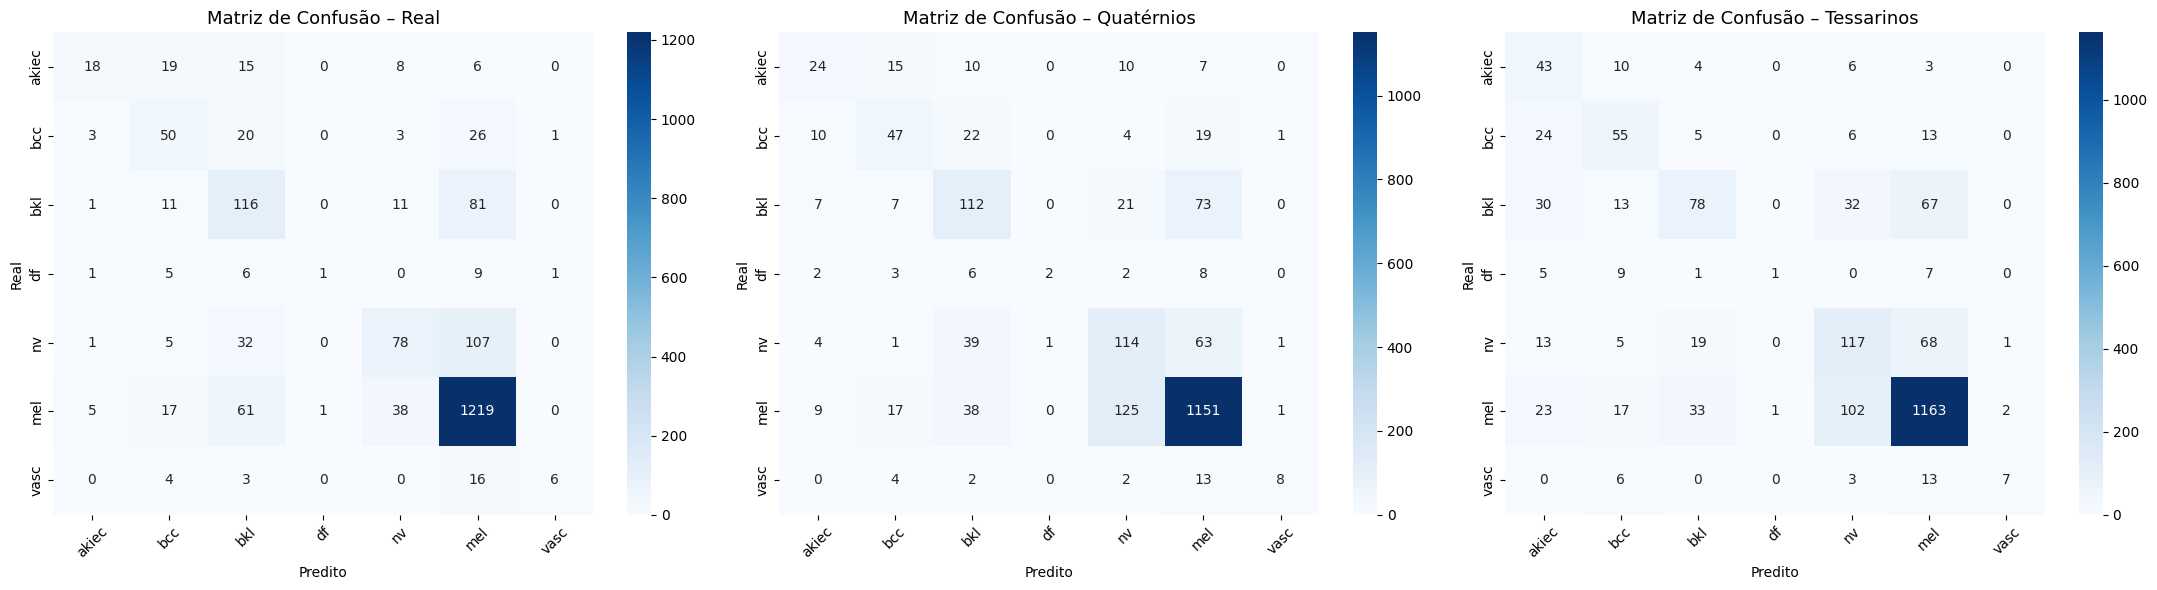

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

modelos = [
    ('Real',       y_pred_real),
    ('Quatérnios', y_pred_quat),
    ('Tessarinos', y_pred_tess),
]

for ax, (nome, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=DermaMNIST_CLASSES,
        yticklabels=DermaMNIST_CLASSES,
        ax=ax
    )
    ax.set_title(f'Matriz de Confusão – {nome}', fontsize=13)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

resultados = []
for nome, y_pred in [
    ('Real',       y_pred_real),
    ('Quatérnios', y_pred_quat),
    ('Tessarinos', y_pred_tess),
]:
    resultados.append({
        'Modelo':             nome,
        'Acurácia':           round(accuracy_score(y_true, y_pred), 4),
        'Acurácia Balanceada': round(balanced_accuracy_score(y_true, y_pred), 4),
        'F1 Macro':           round(f1_score(y_true, y_pred, average='macro'),    4),
        'F1 Ponderado':       round(f1_score(y_true, y_pred, average='weighted'), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print(df_resultados.to_string())
df_resultados

            Acurácia  F1 Macro  F1 Ponderado
Modelo                                      
Real          0.7421    0.4346        0.7253
Quatérnios    0.7272    0.4627        0.7259
Tessarinos    0.7302    0.4495        0.7282


,Acurácia,F1 Macro,F1 Ponderado
Modelo,,,
Real,0.7421,0.4346,0.7253
Quatérnios,0.7272,0.4627,0.7259
Tessarinos,0.7302,0.4495,0.7282


## Gráficos

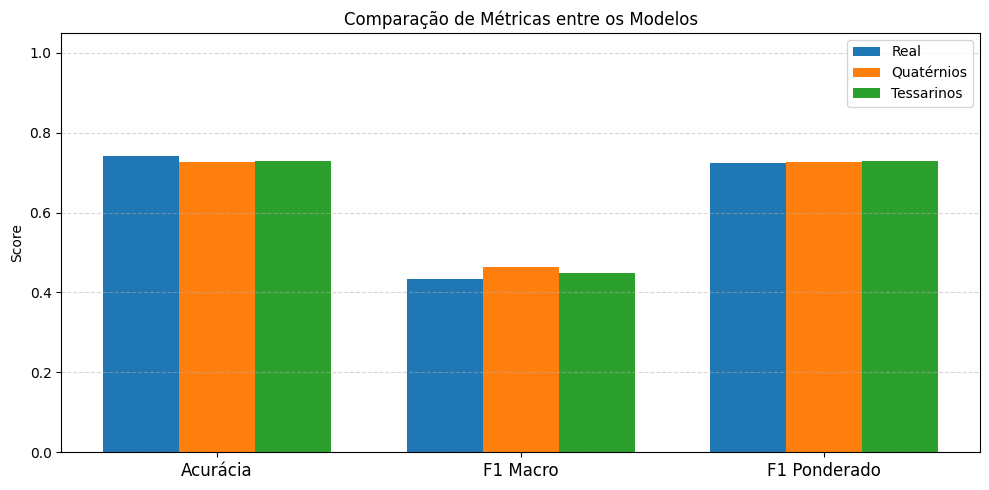

In [ ]:
metricas = ['Acurácia', 'F1 Macro', 'F1 Ponderado']
x = np.arange(len(metricas))
largura = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, modelo in enumerate(df_resultados.index):
    valores = [df_resultados.loc[modelo, m] for m in metricas]
    ax.bar(x + i * largura, valores, largura, label=modelo)

ax.set_xticks(x + largura)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas entre os Modelos')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

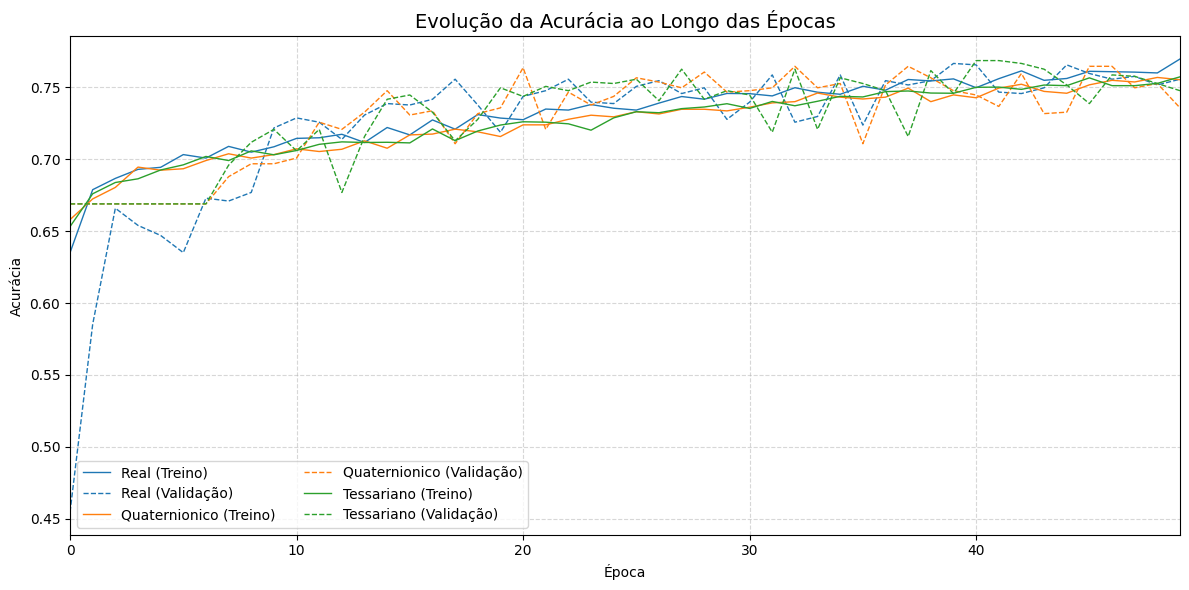

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Modelo Real
plt.plot(
    historico_real.history['accuracy'],
    label='Real (Treino)',
    color='tab:blue',
    linewidth=1
)
plt.plot(
    historico_real.history['val_accuracy'],
    '--',
    label='Real (Validação)',
    color='tab:blue',
    linewidth=1
)

# Modelo Quaternionico
plt.plot(
    historico_quat.history['accuracy'],
    label='Quaternionico (Treino)',
    color='tab:orange',
    linewidth=1
)
plt.plot(
    historico_quat.history['val_accuracy'],
    '--',
    label='Quaternionico (Validação)',
    color='tab:orange',
    linewidth=1
)

# Modelo Tessariano
plt.plot(
    historico_tess.history['accuracy'],
    label='Tessariano (Treino)',
    color='tab:green',
    linewidth=1
)
plt.plot(
    historico_tess.history['val_accuracy'],
    '--',
    label='Tessariano (Validação)',
    color='tab:green',
    linewidth=1
)

plt.title('Evolução da Acurácia ao Longo das Épocas', fontsize=14)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(ncol=2)
plt.xlim(0, len(historico_real.history['accuracy']) - 1)

plt.tight_layout()
plt.show()